In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

Plot distribution of m200
Save the plot data points in txt
Check what's wrong with bootstrap

In [2]:
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis
from myproject.listRedshiftGalaxys import ListRedshiftGalaxy
from myproject.utilities.snapshotEnum import SnapshotEnum

In [3]:
allSnapshotEnums = SnapshotEnum.getAllSnapshots()
# allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]

#get rid of snapshots < 50:
allSnapshotEnums = [snapshotEnum for snapshotEnum in allSnapshotEnums if snapshotEnum[0] >= 50]
allSnapshots = [snapshotEnum[0] for snapshotEnum in allSnapshotEnums]
print(allSnapshots)

[99, 91, 84, 78, 72, 67, 59, 50]


In [4]:
listRedshiftGalaxyAnalysis = ListRedshiftGalaxy()
listRedshiftGalaxyAnalysis.initializeAllGalaxyAnalysis(snapshot_enums=allSnapshots, simulation='TNG300-1', luminosityType='SDSS', generalErrorbar='poisson', generalRewrite=True)
# galaxyAnalysisZ0 = GalaxyAnalysis(generalRewrite=True)

Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
Progress: 3367/3367g Galaxy Group ID 3732 / 3732
Loaded 3367 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
total to process: 3367
total to process: 3366alaxy Group ID 3367 / 3367
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
Progress: 3006/3006g Galaxy

In [9]:
print(listRedshiftGalaxyAnalysis.getAllLoadedSnapshots())
print(SnapshotEnum.SNAPSHOT_99.value[0])
galaxyAnalysisZ0 = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(SnapshotEnum.SNAPSHOT_99.value[0])

[99, 91, 84, 78, 72, 67, 59, 50]
99


In [ ]:
galaxyAnalysisZ0.computeAllPlots()

In [ ]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0])
    galaxyAnalysisZ0.computeAllPlots()
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()

# check snaphot compared to z=0

In [4]:
galaxyAnalysisZ0TNG300 = GalaxyAnalysis(generalRewrite=True, sim='TNG300-1',luminosityType='SDSS')

Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [6]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for i, snapshot in enumerate(SnapshotEnum.getAllSnapshots()):
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0])

    listRedshiftGG = []
    groupList = []
    groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG300-1'))
    groupList.append((galaxyAnalysisZ0TNG300.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG300-1'))

    listRedshiftGG.append(groupList)
    
    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, typePlot='polar', oneaxis=True)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right')  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_vs_SDSS_tng300z0_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

Processing snapshot 91...
Progress: 3367/3367
Loaded 3367 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
total to process: 3367
total to process: 3366alaxy Group ID 3367 / 3367
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p1, TNG300-1
Total Galaxy Groups to process: 220 with pairs : 1647602
Processing Subhalo 102/102 in Galaxy Group ID 99 with total pairs 51513COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG300-1
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 26/550 in Galaxy Group ID 0 with total pairs 150975

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p1/plots/pairwise_polar_difference_tng300z0.1_vs_SDSS_tng300z0_TNG300-1
Processing snapshot 84...


Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
Processing snapshot 91...xy Group ID 3732 / 3732
Progress: 3367/3367
Loaded 3367 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
total to process: 3367
total to process: 3366alaxy Group ID 3367 / 3367
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
Progres

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 112/112 in Galaxy Group ID 99 with total pairs 62160Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p1/plots/pairwise_polar_difference_tng300z0.1_vs_tng300z0.1_default_luminosity_TNG300-1
Processing snapshot 84...
Progress: 3006/3006
Loaded 3006 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
total to process: 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
Progress: 3006/3006g Galaxy Group ID 3006 / 3006
Loaded 3006 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
total to process: 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Gro

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 96/96 in Galaxy Group ID 99 with total pairs 4560786Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p2/plots/pairwise_polar_difference_tng300z0.2_vs_tng300z0.2_default_luminosity_TNG300-1
Processing snapshot 78...
Progress: 2664/2664
Loaded 2664 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
total to process: 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
Progress: 2664/2664g Galaxy Group ID 2664 / 2664
Loaded 2664 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
total to process: 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Gro

...

Processing Subhalo 328/328 in Galaxy Group ID 9 with total pairs 536288Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p5/plots/pairwise_polar_difference_tng300z0.5_vs_tng300z0.5_default_luminosity_TNG300-1
Processing snapshot 59...
Progress: 1531/1531
Loaded 1531 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p7/data/galaxy_data_TNG300-1_.hdf5
total to process: 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
Progress: 1531/1531g Galaxy Group ID 1531 / 1531
Loaded 1531 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p7/data/galaxy_data_TNG300-1_.hdf5
total to process: 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Gro

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 249/249 in Galaxy Group ID 9 with total pairs 308765Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p7/plots/pairwise_polar_difference_tng300z0.7_vs_tng300z0.7_default_luminosity_TNG300-1
Processing snapshot 50...
Progress: 900/900
Loaded 900 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z1p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
Progress: 900/900ing Galaxy Group ID 900 / 900
Loaded 900 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z1p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total 

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 132/132 in Galaxy Group ID 8 with total pairs 864658Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/pairwise_polar_difference_tng300z1.0_vs_tng300z1.0_default_luminosity_TNG300-1


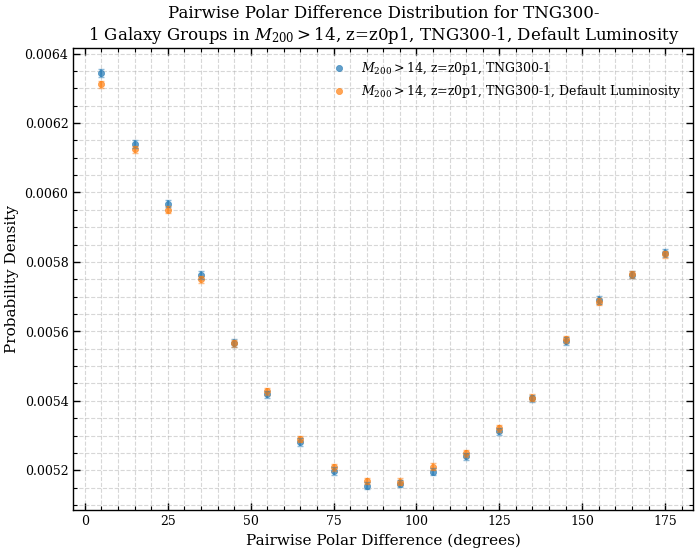

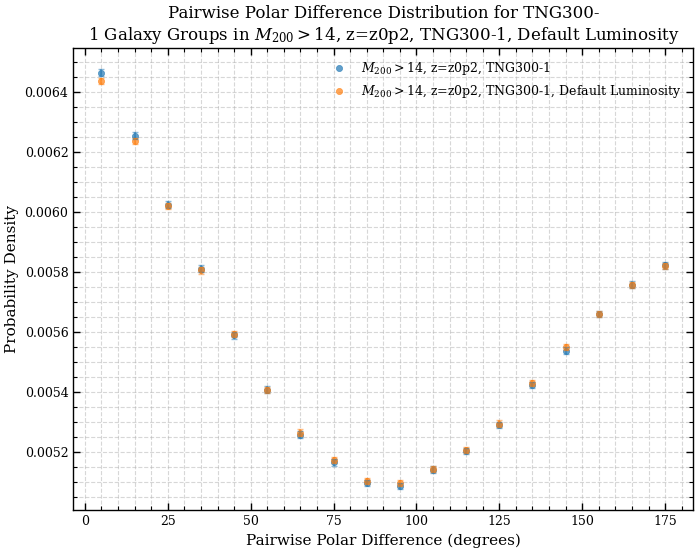

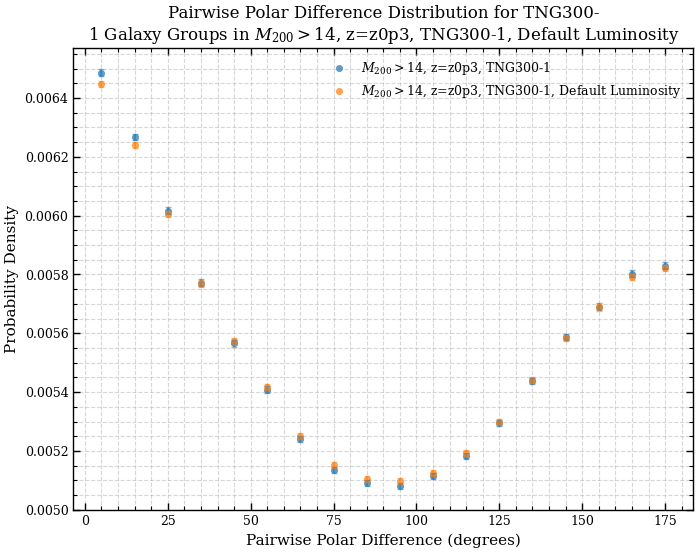

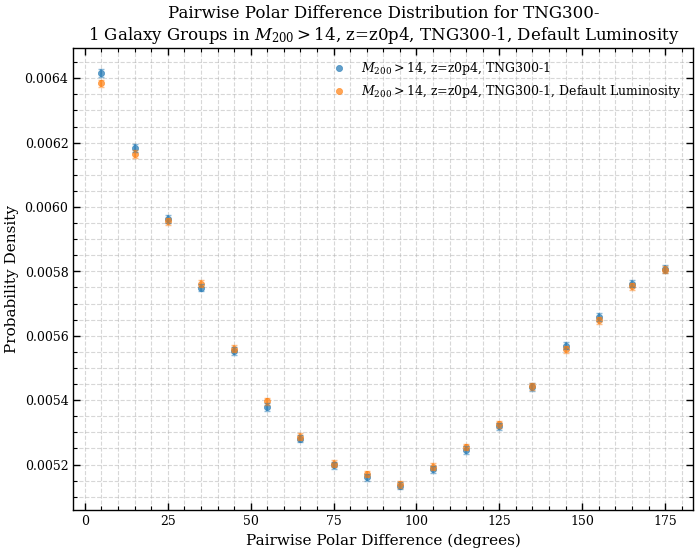

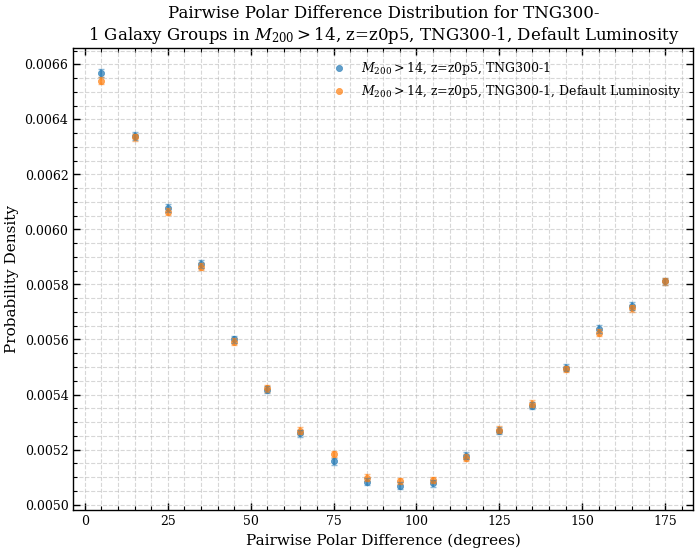

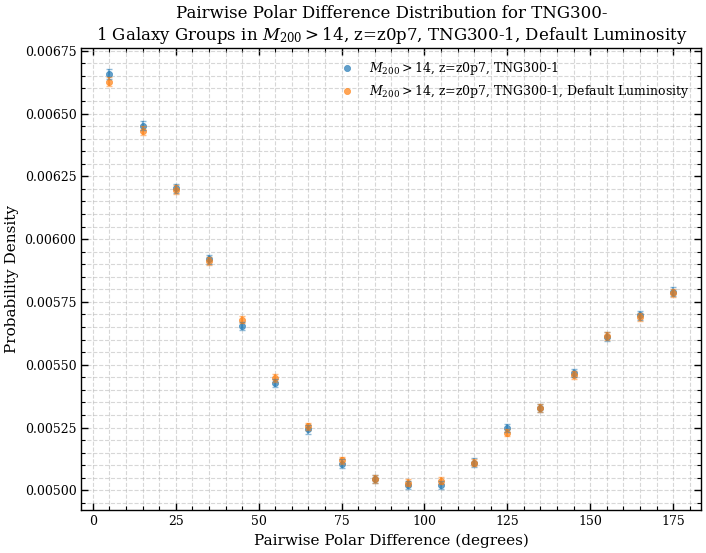

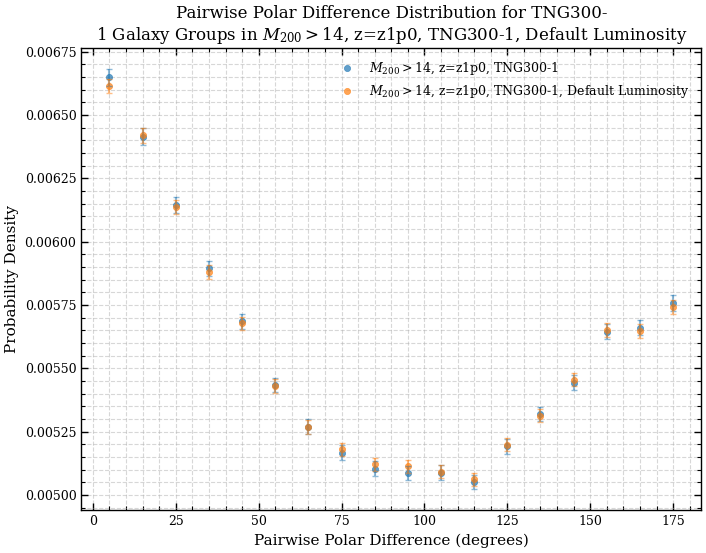

In [5]:
galaxyAnalysisZ0TNG300Default = GalaxyAnalysis(generalRewrite=True, sim='TNG300-1',luminosityType='Default')
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for i, snapshot in enumerate(SnapshotEnum.getAllSnapshots()):
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0])
    galaxyAnalysisZ0TNG300Default.setSnapshot(snapshot[0], luminosityType='Default')

    listRedshiftGG = []
    groupList = []
    groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG300-1'))
    groupList.append((galaxyAnalysisZ0TNG300Default.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0TNG300Default.snapshot_dic[snapshot[0]][1]}, TNG300-1, Default Luminosity'))
    

    listRedshiftGG.append(groupList)
    
    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, typePlot='polar', oneaxis=True)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right')  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_vs_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_default_luminosity_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

Processing snapshot 91...
Progress: 3367/3367
Loaded 3367 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p1/data/galaxy_data_TNG300-1_.hdf5
total to process: 3367
total to process: 3366alaxy Group ID 3367 / 3367
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
total to process: 3366alaxy Group ID 3366 / 3366
final: [np.float64(0.06727626743690919), np.float64(0.08305598729203958), np.float64(0.039708743219627335)]
lenMRL: 660, lenrandom: (220, 3000)tribution for Galaxy Group 220 / 220 with 103 satellites
99th percentile MRL: 0.25809800675607114
Overall number of MRL values above 99th percentile: 79 out of 660
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029164), np.float64(0.10948243303477843)]


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.2851969435172817
Overall number of MRL values above 99th percentile: 81 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p1/plots/mrl_difference_tng300z0.1_vs_tng300z0_TNG300-1
Processing snapshot 84...
Progress: 3006/3006
Loaded 3006 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p2/data/galaxy_data_TNG300-1_.hdf5
total to process: 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
total to process: 3006alaxy Group ID 3006 / 3006
final: [np.float64(0.06578292667682392), np.float64(0.15416648641861602), np.float64(0.14169104270824098)]
lenMRL: 522, lenrandom: (174, 3000)tribution for Galaxy Group 174 / 174 with 92 satel

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.28589199124443027
Overall number of MRL values above 99th percentile: 79 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p2/plots/mrl_difference_tng300z0.2_vs_tng300z0_TNG300-1
Processing snapshot 78...
Progress: 2664/2664
Loaded 2664 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p3/data/galaxy_data_TNG300-1_.hdf5
total to process: 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
total to process: 2664alaxy Group ID 2664 / 2664
final: [np.float64(0.11210911223030663), np.float64(0.09161774232657646), np.float64(0.09437307886899875)]
lenMRL: 393, lenrandom: (131, 3000)tribution for Galaxy Group 131 / 131 with 73 sate

...

lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.28536515794304385
Overall number of MRL values above 99th percentile: 80 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p5/plots/mrl_difference_tng300z0.5_vs_tng300z0_TNG300-1
Processing snapshot 59...
Progress: 1531/1531
Loaded 1531 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p7/data/galaxy_data_TNG300-1_.hdf5
total to process: 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
total to process: 1531alaxy Group ID 1531 / 1531
final: [np.float64(0.16542763499370366), np.float64(0.1966326119423784), np.float64(0.14821200239290197)]
lenMRL: 102, lenrandom: (34, 3000)stribution for Galaxy Group 34 / 34 with 231 satell

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.2859511999748071
Overall number of MRL values above 99th percentile: 79 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p7/plots/mrl_difference_tng300z0.7_vs_tng300z0_TNG300-1
Processing snapshot 50...
Progress: 900/900
Loaded 900 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z1p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
total to process: 900Galaxy Group ID 900 / 900
final: [np.float64(0.2210880946877993), np.float64(0.19496764891902507), np.float64(0.09695619315734465)]
lenMRL: 30, lenrandom: (10, 3000)istribution for Galaxy Group 10 / 10 with 121 satellites
99th percent

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


lenMRL: 840, lenrandom: (280, 3000)tribution for Galaxy Group 280 / 280 with 55 satellitess
99th percentile MRL: 0.2845650168701842
Overall number of MRL values above 99th percentile: 82 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/mrl_difference_tng300z1.0_vs_tng300z0_TNG300-1


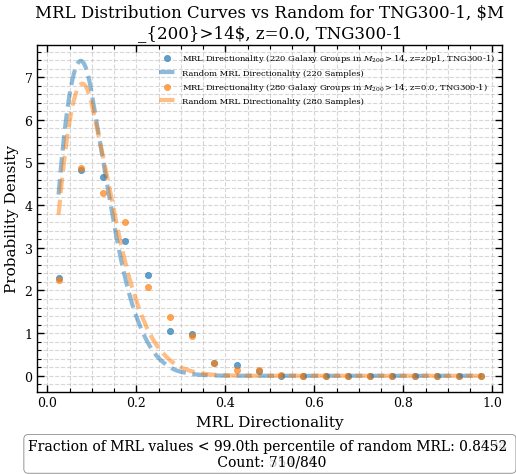

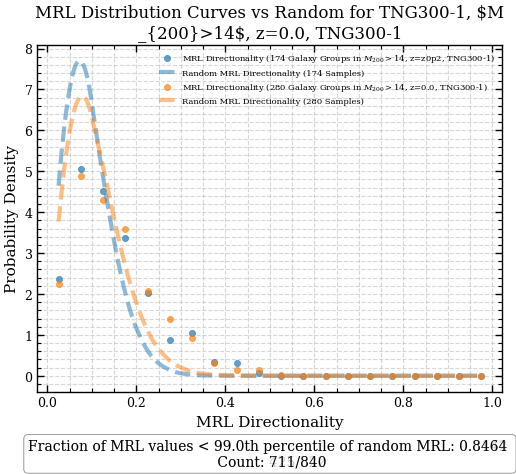

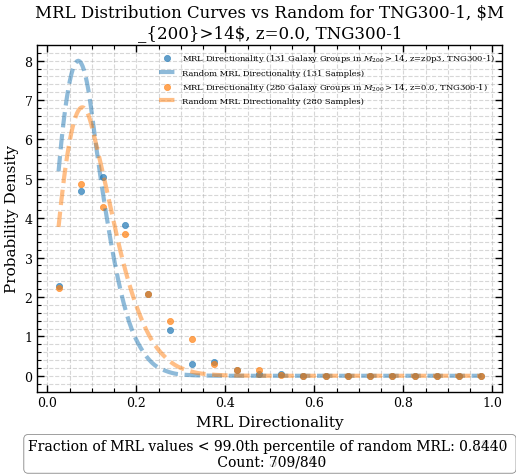

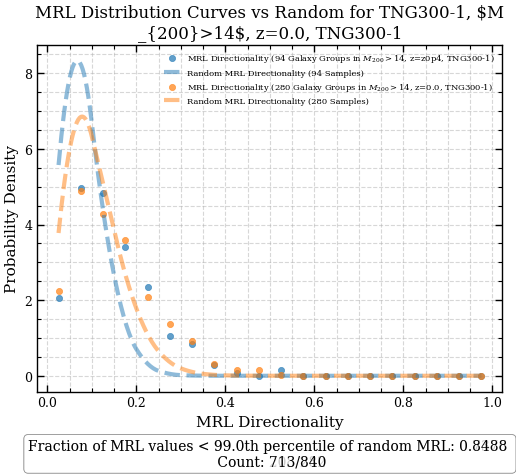

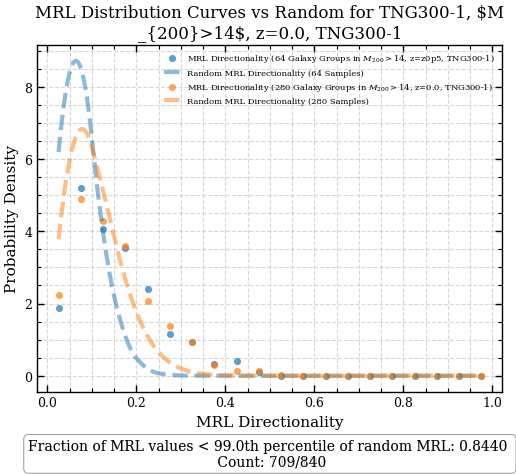

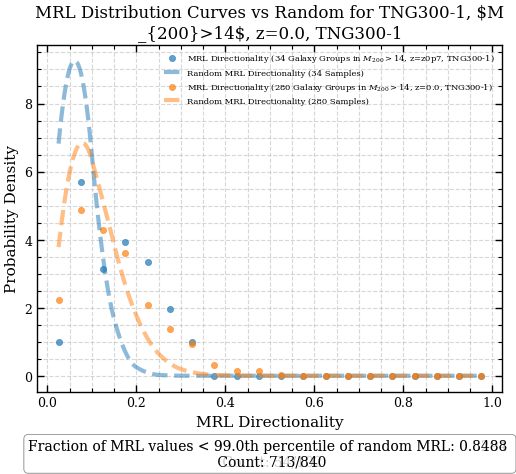

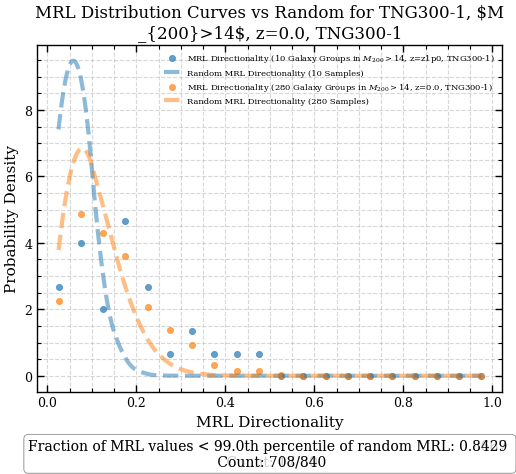

In [14]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for i, snapshot in enumerate(SnapshotEnum.getAllSnapshots()):
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    # if snapshot[0] != 91: #already processed these snapshots
    #     continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")

    galaxyAnalysisZ0.setSnapshot(snapshot[0])

    listRedshiftGG = []

    listRedshiftGG.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG300-1'))
    listRedshiftGG.append((galaxyAnalysisZ0TNG300.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG300-1'))


    
    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlayMRLAndMRLRandom(listGG=listRedshiftGG,oneaxis=True, savefig=False)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right', fontsize=6)  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/mrl_difference_tng300z{SnapshotEnum.getAllSnapshots()[i][1]}_vs_tng300z0_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

# overall change dependence

In [6]:
# get the percent of clusters below the 99% / 95% / 90% CL of random MRL, and plot it across redshift
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []
fracBelow99 = []
fracBelow95 = []
fracBelow90 = []

errBelow99 = []
errBelow95 = []
errBelow90 = []


def binomial_sigma(p, n):
    p = float(p)
    n = int(n)
    if n <= 0:
        return 0.0
    return float(np.sqrt(p * (1.0 - p) / n))


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    redshifts.append(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][1])

    # Note: getPercentOfClustersAboveRandomMRLCL returns the fraction/count/total *below* the percentile.
    (f99, c99, n99), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=99
    )
    (f95, c95, n95), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=95
    )
    (f90, c90, n90), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
        galaxyAnalysisSnapshot.filtered_gt14_list_of_galaxy_groups, percentageMRL=90
    )

    fracBelow99.append(f99)
    fracBelow95.append(f95)
    fracBelow90.append(f90)

    errBelow99.append(binomial_sigma(f99, n99))
    errBelow95.append(binomial_sigma(f95, n95))
    errBelow90.append(binomial_sigma(f90, n90))

Processing snapshot 99...
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029163), np.float64(0.10948243303477843)]
Fraction of MRL values below the 99th percentile of random MRL values: 0.8512 (715/840)tess
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029163), np.float64(0.10948243303477843)]
Fraction of MRL values below the 95th percentile of random MRL values: 0.7476 (628/840)tess
final: [np.float64(0.09720930037101629), np.float64(0.07706537088029163), np.float64(0.10948243303477843)]
Fraction of MRL values below the 90th percentile of random MRL values: 0.6810 (572/840)tess
Processing snapshot 91...
final: [np.float64(0.06727626743690918), np.float64(0.08305598729203961), np.float64(0.039708743219627335)]
Fraction of MRL values below the 99th percentile of random MRL values: 0.8364 (552/660)ites
final: [np.float64(0.06727626743690918), np.float64(0.08305598729203961), np.float64(0.039708743219627335)]
Fraction of MRL values below the 95th perce

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/percent_clusters_above_random_MRL_CL_vs_redshift_TNG300-1


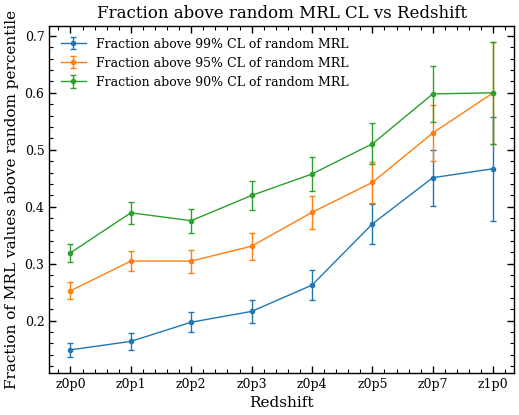

In [17]:
MRL_CL_plotter = AstroPlotter()
MRL_CL_fig, MRL_CL_ax = MRL_CL_plotter.create_figure()

MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow99),
    yerr=errBelow99,
    label='Fraction above 99% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow95),
    yerr=errBelow95,
    label='Fraction above 95% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)
MRL_CL_ax.errorbar(
    redshifts,
    1-np.array(fracBelow90),
    yerr=errBelow90,
    label='Fraction above 90% CL of random MRL',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)

MRL_CL_ax.set_xlabel('Redshift')
MRL_CL_ax.set_ylabel('Fraction of MRL values above random percentile')
MRL_CL_ax.set_title('Fraction above random MRL CL vs Redshift')
MRL_CL_ax.legend(loc='upper left')

MRL_CL_plotter.save_figure(
    MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/percent_clusters_above_random_MRL_CL_vs_redshift_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

In [14]:
# do the same but for the 5 mass groups
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

redshifts = []

mass_bin_labels = [
    '$1e13<M_{200}<1e13.5$',
    '$1e13.5<M_{200}<1e14$',
    '$1e14<M_{200}<1e14.5$',
    '$1e14.5<M_{200}<1e15$',
    '$M_{200}>1e15$',
]

fracBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
fracBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]

errBelow99_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow95_mass_bins = [[] for _ in range(len(mass_bin_labels))]
errBelow90_mass_bins = [[] for _ in range(len(mass_bin_labels))]


def binomial_sigma(p, n):
    p = float(p)
    n = int(n)
    if n <= 0:
        return 0.0
    return float(np.sqrt(p * (1.0 - p) / n))


for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue  # too high redshift

    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])

    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]

    redshifts.append(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][1])

    for i, mass_bin in enumerate(mass_bins):
        random_MRL_values = mass_bin.compute_MRL_random_distribution_curves_for_LGG(
            parallelize=False, num_samples=1000
        )

        (f99, c99, n99), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=99, random_mrl_values=random_MRL_values
        )
        (f95, c95, n95), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=95, random_mrl_values=random_MRL_values
        )
        (f90, c90, n90), _, _ = galaxyAnalysisSnapshot.getPercentOfClustersAboveRandomMRLCL(
            mass_bin, percentageMRL=90, random_mrl_values=random_MRL_values
        )

        fracBelow99_mass_bins[i].append(f99)
        fracBelow95_mass_bins[i].append(f95)
        fracBelow90_mass_bins[i].append(f90)

        errBelow99_mass_bins[i].append(binomial_sigma(f99, n99))
        errBelow95_mass_bins[i].append(binomial_sigma(f95, n95))
        errBelow90_mass_bins[i].append(binomial_sigma(f90, n90))

Processing snapshot 99...
Fraction of MRL values below the 99th percentile of random MRL values: 0.9564 (8699/9096)tes
Fraction of MRL values below the 95th percentile of random MRL values: 0.8978 (8166/9096)
Fraction of MRL values below the 90th percentile of random MRL values: 0.8383 (7625/9096)
Fraction of MRL values below the 99th percentile of random MRL values: 0.9365 (1180/1260)s
Fraction of MRL values below the 95th percentile of random MRL values: 0.8635 (1088/1260)
Fraction of MRL values below the 90th percentile of random MRL values: 0.7913 (997/1260)
Fraction of MRL values below the 99th percentile of random MRL values: 0.8682 (698/804)tess
Fraction of MRL values below the 95th percentile of random MRL values: 0.7699 (619/804)
Fraction of MRL values below the 90th percentile of random MRL values: 0.6953 (559/804)
Fraction of MRL values below the 99th percentile of random MRL values: 0.5185 (14/27)es
Fraction of MRL values below the 95th percentile of random MRL values: 0.51

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/percent_clusters_above_random_MRL_CL_vs_redshift_for_mass_bins_TNG300-1


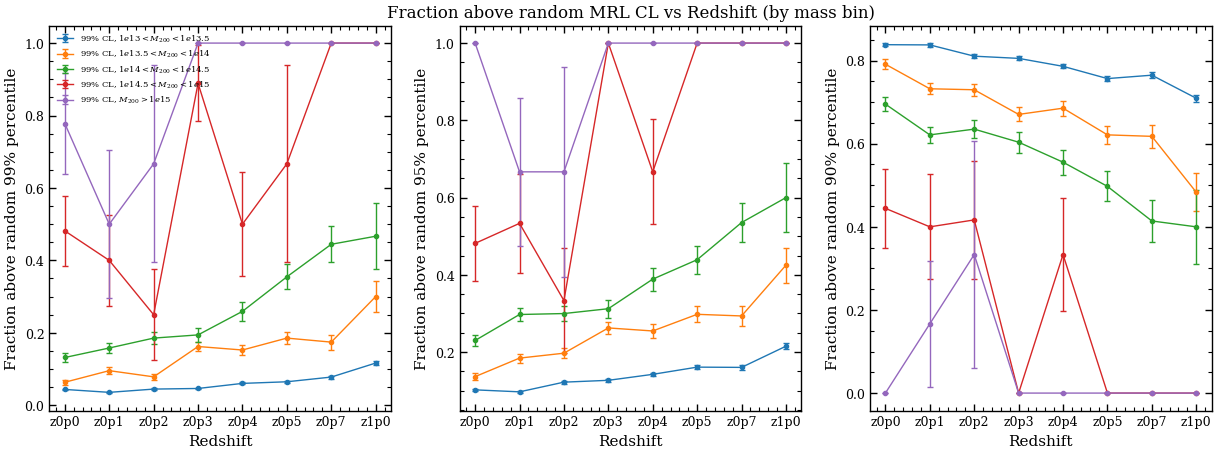

In [18]:
mass_bin_MRL_CL_plotter = AstroPlotter()
mass_bin_MRL_CL_fig, mass_bin_MRL_CL_ax = mass_bin_MRL_CL_plotter.create_figure(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
)  # each col is a different confidence level, each line is a different mass bin

for i in range(len(mass_bin_labels)):
    mass_bin_MRL_CL_ax[0].errorbar(
        redshifts,
        1-np.array(fracBelow99_mass_bins[i]),
        yerr=errBelow99_mass_bins[i],
        label=f'99% CL, {mass_bin_labels[i]}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )
    mass_bin_MRL_CL_ax[1].errorbar(
        redshifts,
        1-np.array(fracBelow95_mass_bins[i]),
        yerr=errBelow95_mass_bins[i],
        label=f'95% CL, {mass_bin_labels[i]}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )
    mass_bin_MRL_CL_ax[2].errorbar(
        redshifts,
        np.array(fracBelow90_mass_bins[i]),
        yerr=errBelow90_mass_bins[i],
        label=f'90% CL, {mass_bin_labels[i]}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )

mass_bin_MRL_CL_ax[0].set_xlabel('Redshift')
mass_bin_MRL_CL_ax[1].set_xlabel('Redshift')
mass_bin_MRL_CL_ax[2].set_xlabel('Redshift')

mass_bin_MRL_CL_ax[0].set_ylabel('Fraction above random 99% percentile')
mass_bin_MRL_CL_ax[1].set_ylabel('Fraction above random 95% percentile')
mass_bin_MRL_CL_ax[2].set_ylabel('Fraction above random 90% percentile')

mass_bin_MRL_CL_ax[1].set_title('Fraction above random MRL CL vs Redshift (by mass bin)')

mass_bin_MRL_CL_ax[0].legend(fontsize=6, loc='upper left')

mass_bin_MRL_CL_plotter.save_figure(
    mass_bin_MRL_CL_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/percent_clusters_above_random_MRL_CL_vs_redshift_for_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)

In [5]:
#take the difference of polar pairwise < 90º with polar pairwise > 90º and plot it across redshift for the full sample and for the 5 mass bins
from myproject.utilities.snapshotEnum import SnapshotEnum
from myproject.utilities.plottingTools import AstroPlotter
import numpy as np

def polar_lt90_ge90_stats_from_hist(angles_deg, bin_size_deg=5.0):
    """
    Compute counts and fractions using a (normalized) histogram with an edge at 90°.

    Returns a dict with:
      - total
      - n_lt90, n_ge90 (expected counts from histogram; equals counts for equal weights)
      - frac_lt90, frac_ge90 (fractions; sum to 1 when total>0)
      - diff = n_lt90 - n_ge90
      - sigma_poisson = sqrt(n_lt90 + n_ge90)
    """
    angles = np.asarray(angles_deg, dtype=float)
    if angles.size == 0:
        return {
            'total': 0,
            'n_lt90': 0.0,
            'n_ge90': 0.0,
            'frac_lt90': 0.0,
            'frac_ge90': 0.0,
            'diff': 0.0,
            'sigma_poisson': 0.0,
        }
    bins = np.arange(0.0, 180.0 + bin_size_deg, bin_size_deg)
    counts, edges = np.histogram(angles, bins=bins)
    total = int(counts.sum())
    if total == 0:
        return {
            'total': 0,
            'n_lt90': 0.0,
            'n_ge90': 0.0,
            'frac_lt90': 0.0,
            'frac_ge90': 0.0,
            'diff': 0.0,
            'sigma_poisson': 0.0,
        }
    # normalized histogram (probability mass per bin)
    prob = counts / total
    lt_mask = edges[:-1] < 90.0  # bins with left edge < 90° are counted as <90° (e.g. [85,90))
    frac_lt90 = float(prob[lt_mask].sum())
    frac_ge90 = float(prob[~lt_mask].sum())
    # expected counts from normalized histogram
    n_lt90 = frac_lt90 * total
    n_ge90 = frac_ge90 * total
    diff = n_lt90 - n_ge90
    sigma_poisson = float(np.sqrt(n_lt90 + n_ge90))
    return {
        'total': total,
        'n_lt90': float(n_lt90),
        'n_ge90': float(n_ge90),
        'frac_lt90': float(frac_lt90),
        'frac_ge90': float(frac_ge90),
        'diff': float(diff),
        'sigma_poisson': float(sigma_poisson),
    }

redshifts = []

# values used for plotting (counts-difference + poisson errors)
polarDifference_full_sample = []
polarDifference_full_sample_err = []
polarDifference_mass_bins = []
polarDifference_mass_bins_err = []

# keep both expected counts and fractions for later inspection/analysis
full_total_pairs = []
full_n_lt90 = []
full_n_ge90 = []
full_frac_lt90 = []
full_frac_ge90 = []

mass_bin_labels = ['$1e13<M_{200}<1e13.5$', '$1e13.5<M_{200}<1e14$', '$1e14<M_{200}<1e14.5$', '$1e14.5<M_{200}<1e15$', '$M_{200}>1e15$']
mass_total_pairs = [[] for _ in range(len(mass_bin_labels))]
mass_n_lt90 = [[] for _ in range(len(mass_bin_labels))]
mass_n_ge90 = [[] for _ in range(len(mass_bin_labels))]
mass_frac_lt90 = [[] for _ in range(len(mass_bin_labels))]
mass_frac_ge90 = [[] for _ in range(len(mass_bin_labels))]

polarDifference_mass_bins = [[] for _ in range(len(mass_bin_labels))]
polarDifference_mass_bins_err = [[] for _ in range(len(mass_bin_labels))]

for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisSnapshot = listRedshiftGalaxyAnalysis.getGalaxyAnalysisSnapshot(snapshot[0])
    mass_bins = [
        galaxyAnalysisSnapshot.filtered_gt13_ls13p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt13p5_ls14_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14_ls14p5_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt14p5_ls15_list_of_galaxy_groups,
        galaxyAnalysisSnapshot.filtered_gt15_list_of_galaxy_groups,
    ]
    redshifts.append(galaxyAnalysisSnapshot.snapshot_dic[snapshot[0]][1])
    
    # Build the "full sample" by accumulating angles from the mass bins,
    # so we don't recompute the polar differences twice.
    full_angles = []
    for i, mass_bin in enumerate(mass_bins):
        polarRawValues = mass_bin.compute_probablity_distribution_of_polar_differences()
        full_angles.extend(polarRawValues)
        stats = polar_lt90_ge90_stats_from_hist(polarRawValues, bin_size_deg=5.0)
        polarDifference_mass_bins[i].append(stats['diff'])
        polarDifference_mass_bins_err[i].append(stats['sigma_poisson'])
        mass_total_pairs[i].append(stats['total'])
        mass_n_lt90[i].append(stats['n_lt90'])
        mass_n_ge90[i].append(stats['n_ge90'])
        mass_frac_lt90[i].append(stats['frac_lt90'])
        mass_frac_ge90[i].append(stats['frac_ge90'])
    
    stats_full = polar_lt90_ge90_stats_from_hist(full_angles, bin_size_deg=5.0)
    polarDifference_full_sample.append(stats_full['diff'])
    polarDifference_full_sample_err.append(stats_full['sigma_poisson'])
    full_total_pairs.append(stats_full['total'])
    full_n_lt90.append(stats_full['n_lt90'])
    full_n_ge90.append(stats_full['n_ge90'])
    full_frac_lt90.append(stats_full['frac_lt90'])
    full_frac_ge90.append(stats_full['frac_ge90'])

Processing snapshot 99...
Total Galaxy Groups to process: 3032 with pairs : 197451
Processing Subhalo 12/12 in Galaxy Group ID 999 with total pairs 6615Total Galaxy Groups to process: 420 with pairs : 215155
Processing Subhalo 22/22 in Galaxy Group ID 946 with total pairs 2318Total Galaxy Groups to process: 268 with pairs : 1036997
Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606Total Galaxy Groups to process: 9 with pairs : 340811
Processing Subhalo 267/267 in Galaxy Group ID 9 with total pairs 355118Total Galaxy Groups to process: 3 with pairs : 376094
Processing Subhalo 386/386 in Galaxy Group ID 2 with total pairs 743051Processing snapshot 91...
Total Galaxy Groups to process: 2790 with pairs : 252880
Processing Subhalo 13/13 in Galaxy Group ID 1000 with total pairs 785Total Galaxy Groups to process: 356 with pairs : 244464
Processing Subhalo 63/63 in Galaxy Group ID 89 with total pairs 19536Total Galaxy Groups to process: 213 with pairs : 1119755
Processing 

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_TNG300-1


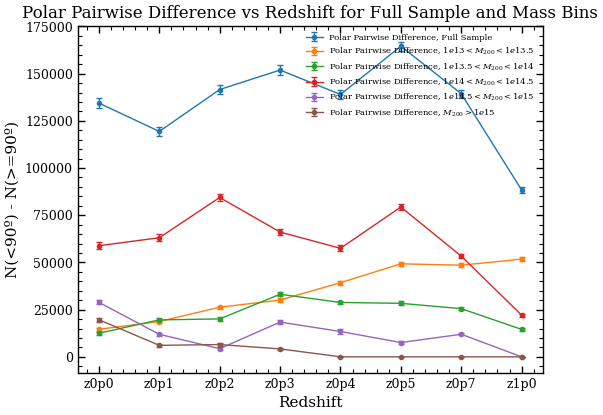

In [20]:
polarPairwiseDifference_plotter = AstroPlotter()
polarPairwiseDifference_fig, polarPairwiseDifference_ax = polarPairwiseDifference_plotter.create_figure()
polarPairwiseDifference_ax.errorbar(
    redshifts,
    polarDifference_full_sample,
    yerr=polarDifference_full_sample_err,
    label='Polar Pairwise Difference, Full Sample',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
    )
for i in range(len(mass_bin_labels)):
    polarPairwiseDifference_ax.errorbar(
        redshifts,
        polarDifference_mass_bins[i],
        yerr=polarDifference_mass_bins_err[i],
        label=f'Polar Pairwise Difference, {mass_bin_labels[i]}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )
polarPairwiseDifference_ax.set_xlabel('Redshift')
polarPairwiseDifference_ax.set_ylabel('N(<90º) - N(>=90º)')
polarPairwiseDifference_ax.set_title('Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')
polarPairwiseDifference_ax.legend(fontsize=6)
polarPairwiseDifference_plotter.save_figure(polarPairwiseDifference_fig, galaxyAnalysisSnapshot.scratchPlotDirc + f'/polar_pairwise_difference_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}')

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z1p0/plots/polar_pairwise_difference_normalized_vs_redshift_for_full_sample_and_mass_bins_TNG300-1


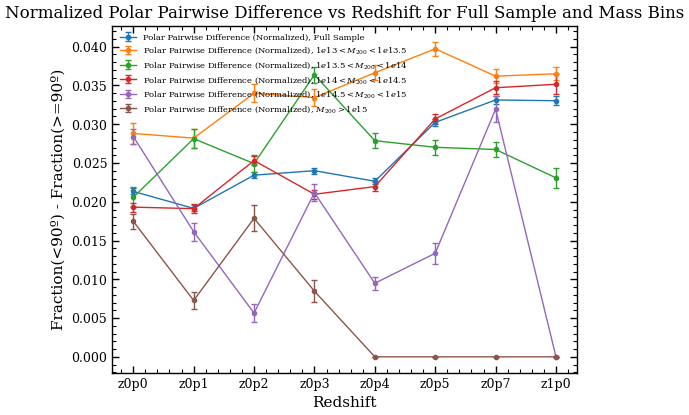

In [23]:
# plot the normalized version of the above (frac(<90º) - frac(>=90º)) vs redshift for the full sample and mass bins
# Uncertainty: treat counts as multinomial with fixed N per snapshot.
# For d = f_lt - f_ge (with f_lt + f_ge = 1), Var(d) = (1 - d^2) / N = 4 f_lt (1-f_lt) / N.
import numpy as np


def frac_diff_and_sigma(frac_lt, frac_ge, n_total):
    d = float(frac_lt) - float(frac_ge)
    n = int(n_total)
    if n <= 0:
        return d, 0.0
    sigma = float(np.sqrt(max(0.0, 1.0 - d * d) / n))
    return d, sigma


full_frac_diff = []
full_frac_diff_err = []
for frac_lt, frac_ge, n in zip(full_frac_lt90, full_frac_ge90, full_total_pairs):
    d, s = frac_diff_and_sigma(frac_lt, frac_ge, n)
    full_frac_diff.append(d)
    full_frac_diff_err.append(s)

mass_frac_diff = [[] for _ in range(len(mass_bin_labels))]
mass_frac_diff_err = [[] for _ in range(len(mass_bin_labels))]
for i in range(len(mass_bin_labels)):
    for frac_lt, frac_ge, n in zip(mass_frac_lt90[i], mass_frac_ge90[i], mass_total_pairs[i]):
        d, s = frac_diff_and_sigma(frac_lt, frac_ge, n)
        mass_frac_diff[i].append(d)
        mass_frac_diff_err[i].append(s)

polarPairwiseDifferenceNorm_plotter = AstroPlotter()
polarPairwiseDifferenceNorm_fig, polarPairwiseDifferenceNorm_ax = polarPairwiseDifferenceNorm_plotter.create_figure()

polarPairwiseDifferenceNorm_ax.errorbar(
    redshifts,
    full_frac_diff,
    yerr=full_frac_diff_err,
    label='Polar Pairwise Difference (Normalized), Full Sample',
    marker='o',
    linestyle='-',
    capsize=2,
    elinewidth=1,
    linewidth=1,
    markersize=3,
)

for i in range(len(mass_bin_labels)):
    polarPairwiseDifferenceNorm_ax.errorbar(
        redshifts,
        mass_frac_diff[i],
        yerr=mass_frac_diff_err[i],
        label=f'Polar Pairwise Difference (Normalized), {mass_bin_labels[i]}',
        marker='o',
        linestyle='-',
        capsize=2,
        elinewidth=1,
        linewidth=1,
        markersize=3,
    )

polarPairwiseDifferenceNorm_ax.set_xlabel('Redshift')
polarPairwiseDifferenceNorm_ax.set_ylabel('Fraction(<90º) - Fraction(>=90º)')
polarPairwiseDifferenceNorm_ax.set_title('Normalized Polar Pairwise Difference vs Redshift for Full Sample and Mass Bins')
polarPairwiseDifferenceNorm_ax.legend(fontsize=6)

polarPairwiseDifferenceNorm_plotter.save_figure(
    polarPairwiseDifferenceNorm_fig,
    galaxyAnalysisSnapshot.scratchPlotDirc
    + f'/polar_pairwise_difference_normalized_vs_redshift_for_full_sample_and_mass_bins_{galaxyAnalysisSnapshot.sim}{galaxyAnalysisSnapshot.plotEndingFormat}',
)